In [1]:
import numpy as np
import torch
import PPO_SIL_double_ac_continuous as PPO_SIL
import matplotlib.pyplot as plt

from HJBQVI_solver import solve_exchange_rate_explicit_impulse

In [2]:
USE_MPS = torch.backends.mps.is_available()
DEVICE = torch.device("mps" if USE_MPS else ("cuda" if torch.cuda.is_available() else "cpu"))
torch.set_default_dtype(torch.float32 if DEVICE.type == "mps" else torch.float64)

common = dict(
    w_const=0.05,
    mu=0.25,
    sigma=0.30,
    beta=0.02,
    gamma=3.0,
    kappa=1.0,
    c=0.10,
    T=1.0,
    m=0.02,
)

n_x = 401      # evaluation only
n_t = 252
n_zeta = 101   # evaluation only; the impulse policy is continuous

In [3]:
n_x = 401
n_t = 252
n_zeta = 101

res = solve_exchange_rate_explicit_impulse(
    w_const=common['w_const'],
    mu=common['mu'],
    sigma=common['sigma'],
    beta=common['beta'],
    gamma=common['gamma'],
    kappa=common['kappa'],
    c=common['c'],
    T=common['T'],
    n_x=n_x,
    m=common['m'],
    n_zeta=n_zeta,
    n_t=n_t,
)

x_grid = res.x_grid
v_m_0 = res.values[0]
print(f'v(0,m): {float(np.interp(common['m'], x_grid, v_m_0))}')

v(0,m): -0.05214544082368151


In [19]:
PPO_SIL_config = PPO_SIL.make_default_config(
    mu=common["mu"],
    sigma=common["sigma"],
    w=common["w_const"],
    m=common["m"],
    beta=common["beta"],
    gamma=common["gamma"],
    kappa=common["kappa"],
    c=common["c"],
    T=common["T"],

    n_t=n_t,
    n_x=n_x,
    n_zeta=n_zeta,

    x_init_min=-2.0,
    x_init_max=2.0,
    x_eval_min=-2.0,
    x_eval_max=2.0,
    x_scale=2.0,

    # Continuous impulse truncation, not a grid.
    zeta_low=-4.0,
    zeta_high=4.0,

    device=str(DEVICE),
    dtype="float32" if DEVICE.type == "mps" else "float64",

    rollout_envs=256,
    eval_envs=512,
    train_iters=150,
    ppo_epochs=5,
    minibatch_size=32768,
    clip_eps=0.5,
    target_kl=0.02,
    gae_lambda=1.0,
    gamma_rl=1.0,
    max_grad_norm=1.0,

    lr=1e-4,
    d_lr=None,   # None means use lr
    u_lr=None,

    d_value_coef=0.5,
    u_value_coef=0.5,
    d_entropy_coef=1e-3,
    u_entropy_coef=1e-3,

    sil_policy_coef=0.03,
    sil_value_coef=0.03,
    sil_entropy_coef=1e-3,
    sil_updates_per_iter=1,
    sil_warmup_iters=3,
    sil_batch_size=2048,
    sil_buffer_capacity=50000,
    sil_margin=0.02,

    save_dir="./PPO models double AC continuous/",
    hidden_layers=2,
    hidden_dim=512,
    activation="tanh",
    layer_norm=False,

    # Initial intervention logit bias.
    # Increase toward 0.0 or positive values if the d-policy collapses to no intervention too early.
    decision_logit_bias=0.1,

    # Continuous impulse policy standard deviation.
    u_log_std_init=-0.25,

    eval_every=1000,
    print_every=1,
    seed=42,
)

result = PPO_SIL.train(PPO_SIL_config)

print(PPO_SIL.evaluate_policy(
    result["actor_critic"],
    result["env"],
    num_envs=4096,
    deterministic=True,
))

[iter 0001/150] train=-636.38690 eval=-26.62640 d_pi=-0.0002 d_v= 145383.0453 u_pi=-0.0074 u_v= 146856.8578 ent_d= 0.6924 ent_u= 1.1688 intv= 0.5245 |zeta|= 1.9299
[iter 0002/150] train=-322.76083 eval= nan d_pi=-0.0002 d_v= 19583.1693 u_pi=-0.0017 u_v= 19874.4912 ent_d= 0.6925 ent_u= 1.1679 intv= 0.5169 |zeta|= 1.9309
[iter 0003/150] train=-281.53397 eval= nan d_pi=-0.0004 d_v= 13131.7753 u_pi=-0.0006 u_v= 13379.9497 ent_d= 0.6918 ent_u= 1.1669 intv= 0.4939 |zeta|= 1.9540
[iter 0004/150] train=-266.60751 eval= nan d_pi=-0.0004 d_v= 11636.8965 u_pi=-0.0003 u_v= 11835.4946 ent_d= 0.6885 ent_u= 1.1658 intv= 0.4788 |zeta|= 1.9606
[iter 0005/150] train=-249.50900 eval= nan d_pi=-0.0002 d_v= 10088.2452 u_pi= 0.0002 u_v= 10295.1635 ent_d= 0.6799 ent_u= 1.1649 intv= 0.4440 |zeta|= 1.9601
[iter 0006/150] train=-241.81320 eval= nan d_pi=-0.0003 d_v= 9383.6530 u_pi= 0.0000 u_v= 9783.3150 ent_d= 0.6626 ent_u= 1.1644 intv= 0.4084 |zeta|= 1.9405
[iter 0007/150] train=-231.24876 eval= nan d_pi=-0.00

KeyboardInterrupt: 

In [ ]:
best_model, best_env, best_cfg, ckpt = PPO_SIL.load_actor_critic_from_checkpoint(
    result["best_checkpoint"],
    map_location=str(DEVICE),
)

print(PPO_SIL.evaluate_policy(
    best_model,
    best_env,
    num_envs=4096,
    deterministic=True,
))

{'return_mean': -1.3895195722579956, 'return_std': 1.2524189949035645, 'intervene_rate': 0.0, 'avg_abs_w': 0.05000000819563866, 'avg_abs_jump_if_intervene': 0.0, 'value_d_mean': -0.7168847322463989, 'value_u_mean': -2.3765547275543213, 'value_d_abs_error': 0.31357133388519287, 'value_u_abs_error_intervene': nan}


In [ ]:
x_grid_torch = torch.linspace(
    best_cfg.x_eval_min,
    best_cfg.x_eval_max,
    best_cfg.n_x+1,
    device=best_env.device,
    dtype=best_env.dtype,
)

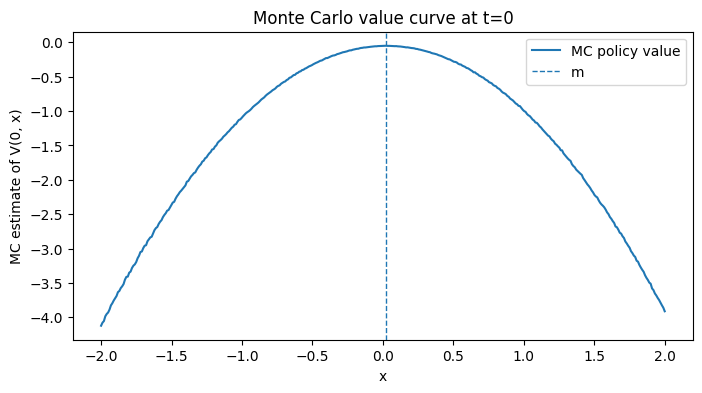

In [ ]:
v_mc = PPO_SIL.mc_value_curve_t0(
    best_model,
    best_env,
    x_grid=x_grid_torch,
    n_paths=4000,
    deterministic=True,
    chunk_size=32,
)

plt.figure(figsize=(8, 4))
plt.plot(x_grid_torch.detach().cpu().numpy(), v_mc, label="MC policy value")
plt.axvline(common["m"], linestyle="--", linewidth=1.0, label="m")
plt.xlabel("x")
plt.ylabel("MC estimate of V(0, x)")
plt.title("Monte Carlo value curve at t=0")
plt.legend()
plt.show()

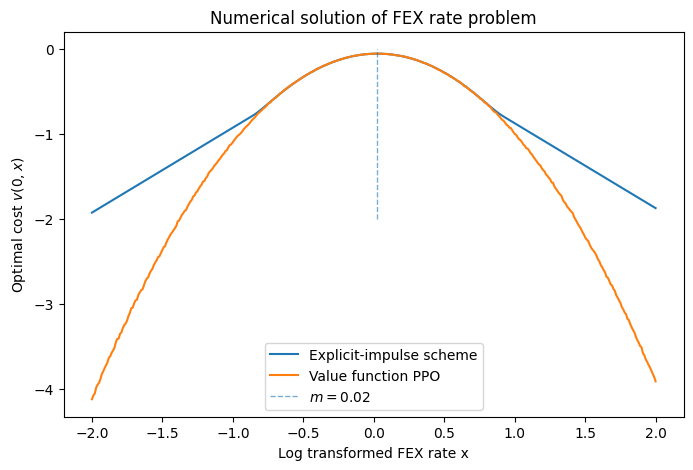

In [ ]:
plt.figure(figsize=(8,5), dpi=100)
plt.plot(x_grid, v_m_0, label='Explicit-impulse scheme')
plt.plot(x_grid, v_mc, label='Value function PPO')
plt.vlines(common['m'], ymax=0.0, ymin=-2, linestyles='--', linewidth=1.0, alpha=0.6, label=rf'$m={common['m']}$')
plt.title('Numerical solution of FEX rate problem')
plt.xlabel('Log transformed FEX rate x')
plt.ylabel(rf'Optimal cost $v(0,x)$')
plt.legend()
plt.show()